<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
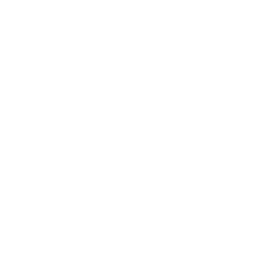
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Trendová analýza EWMA míry chyb v medikaci</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Zdravotnictví / Bezpečnost pacientů &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Shrnutí

Tato analýza sleduje týdenní míru chyb v medikaci na jednotce intenzivní péče (JIP) pomocí **exponenciálně váženého klouzavého průměru (EWMA) regulačního diagramu** z PROC MACONTROL. JIP zavedla nový systém elektronické dokumentace podávání léků (eMAR) v 51. týdnu sledovaného období. Týmy pro bezpečnost pacientů potřebují metodu včasného varování, která rychle upozorní na trvalý nárůst chyb dříve, než se nahromadí čtvrtina hlášení o újmě.

EWMA diagram s vyhlazovací váhou **lambda = 0,3** je sestaven ve dvou fázích. Regulační meze jsou nejprve stanoveny ze stabilního výchozího období před migrací (týdny 1-50), poté je celá 100týdenní řada sledována proti těmto pevným mezím. Diagram zůstává pod kontrolou po celé výchozí období a signalizuje stav mimo kontrolu **první týden po spuštění**, což potvrzuje, že přechod na eMAR se shodoval se skutečným, trvalým posunem míry chyb, a nikoli jen s běžným týdenním šumem.


## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|---------|
| WORK.ICU_ERRORS | Týdenní míra chyb v medikaci na 1 000 podání pro jednu JIP, 100 po sobě jdoucích týdnů | 100 |

Sleduje se jedna JIP po týdnech. Každý záznam obsahuje číslo týdne, míru chyb na 1 000 podání, objem podání a odvozený počet chyb. Zdokumentovaná změna procesu (spuštění eMAR) nastává v týdnu 51 a posouvá základní průměrnou míru chyb nahoru přibližně o 1,6 na 1 000.


---

In [1]:
/* --------------------------------------------------------
   Generování týdenních dat o chybách v medikaci na JIP
   100 po sobě jdoucích týdnů pro jednu JIP.
   Nový systém eMAR se spouští v týdnu 51 a zvyšuje
   základní průměrnou míru chyb z ~3,5 na ~5,1 na 1 000.
   -------------------------------------------------------- */
data work.icu_errors;
    CALL streaminit(42);
    DÉLKA unit_name $12 phase $16;
    unit_name = 'JIP';
    base_rate  = 3.5;   /* průměrná míra před migrací / 1 000 */
    unit_sigma = 0.45;  /* běžný týdenní šum (common-cause) */
    OPAKUJ week_num = 1 TO 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        KDYŽ administrations < 300 PAK administrations = 300;
        /* migrace na eMAR posouvá průměr nahoru po týdnu 50 */
        KDYŽ week_num > 50 PAK OPAKUJ;
            phase = 'PO-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        KONEC;
        JINAK OPAKUJ;
            phase = 'VÝCHOZÍ';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        KONEC;
        KDYŽ error_rate_per_1k < 0 PAK error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        VÝSTUP;
    KONEC;
    ODSTRANIT base_rate unit_sigma;
    FORMÁT week_start_date date9.;
SPUSTIT;



NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                       Míra chyb na JIP: výchozí stav vs. po eMAR                                       

                                                  The MEANS Procedure

                           Analysis Variable : error_rate_per_1k Chybovost na 1 000 podání

        Fáze               N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        PO-eMAR               50           5.11           0.44           3.69           5.96
        VÝCHOZÍ               50           3.50           0.48           2.55           4.71
        ------------------------------------------------------------------------------------

                                      Analysis Variable : error_count Počet chyb

        Fáze               N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


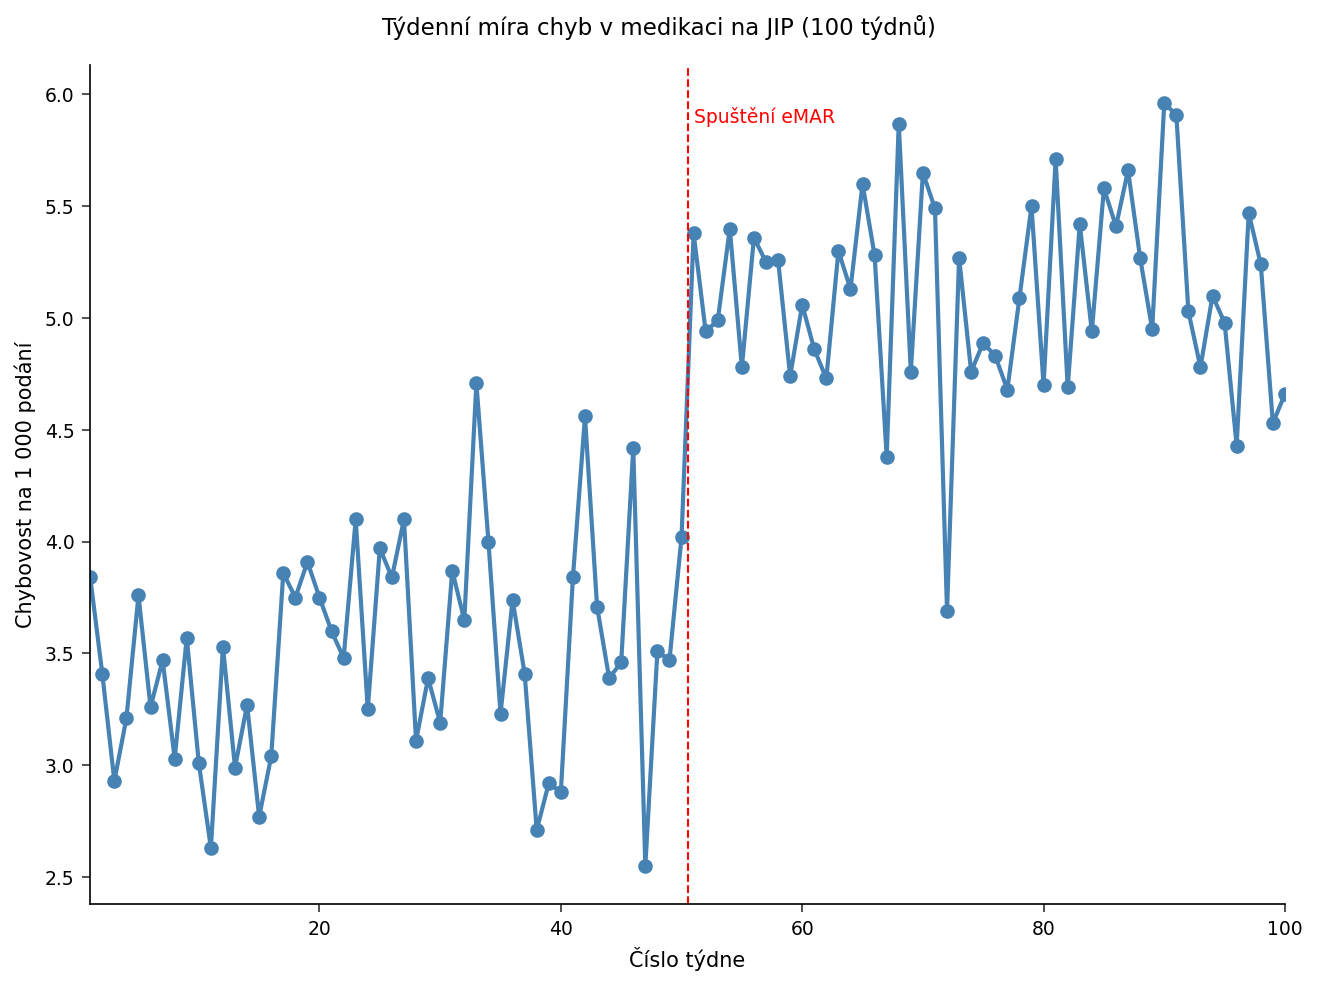

In [2]:
/* --------------------------------------------------------
   Porovnání míry chyb před a po spuštění eMAR,
   a graf týdenního trendu.
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.icu_errors n mean std MIN MAX maxdec=2;
    TŘÍDA phase;
    PROMĚNNÁ error_rate_per_1k error_count administrations;
    ŠTÍTEK phase='Fáze' error_rate_per_1k='Chybovost na 1 000 podání'
          error_count='Počet chyb' administrations='Počet podání';
    NÁZEV 'Míra chyb na JIP: výchozí stav vs. po eMAR';
SPUSTIT;

PROCEDURA SGPLOT data=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   ŠTÍTEK='Spuštění eMAR';
    XAXIS ŠTÍTEK='Číslo týdne';
    YAXIS ŠTÍTEK='Chybovost na 1 000 podání';
    NÁZEV 'Týdenní míra chyb v medikaci na JIP (100 týdnů)';
SPUSTIT;


---

In [3]:
/* --------------------------------------------------------
   Fáze I: stanovení regulačních mezí EWMA ze stabilního
   výchozího období před migrací (týdny 1-50). Tyto pevné
   meze jsou měřítkem pro celé sledované období.
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.icu_errors(KDE=(week_num <= 50)) NOPRINT;
    PROMĚNNÁ error_rate_per_1k;
    VÝSTUP out=work.baseline_stats mean=base_mean std=base_std;
SPUSTIT;

data work.icu_limits;
    NASTAVIT work.baseline_stats;
    DÉLKA _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* výchozí středová hodnota */
    _STDDEV_ = base_std;    /* výchozí common-cause sigma */
    _LIMITN_ = 1;
    PONECHAT _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
SPUSTIT;

PROCEDURA TISK data=work.icu_limits noobs;
    NÁZEV 'Vstupy regulačních mezí Fáze I (výchozí týdny 1-50)';
SPUSTIT;


                                  Vstupy regulačních mezí Fáze I (výchozí týdny 1-50)                                   

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                                  Vstupy regulačních mezí Fáze I (výchozí týdny 1-50)                                   


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/5f9a885d-396c-4890-9942-2232e0d62b2d/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


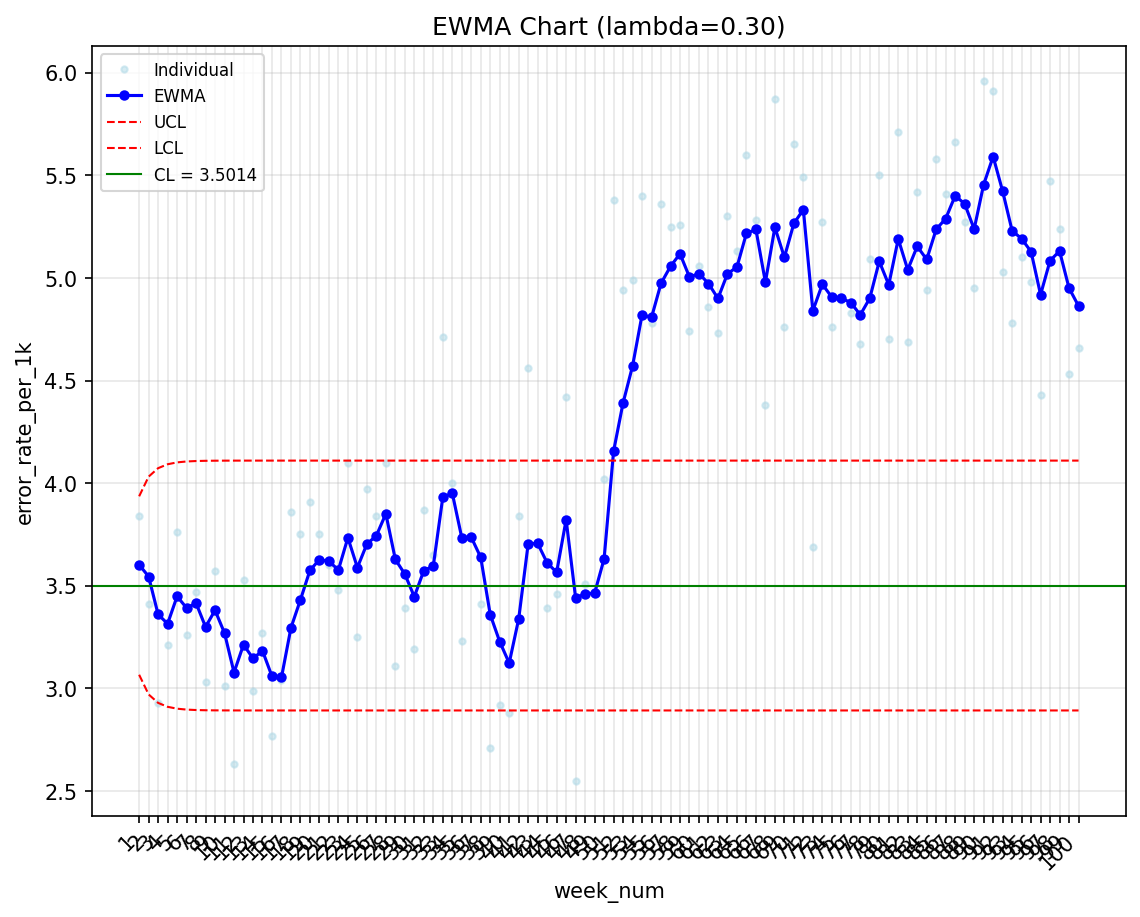

In [4]:
/* --------------------------------------------------------
   Fáze II: sledování celé 100týdenní řady proti pevným
   výchozím mezím. lambda=0,3 dává citlivost vhodnou
   pro sledování bezpečnosti pacientů.
   -------------------------------------------------------- */
PROCEDURA macontrol data=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        VÁHA    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    ŠTÍTEK error_rate_per_1k =
          'Chyby v medikaci na 1 000 podání';
    NÁZEV 'EWMA diagram: míra chyb v medikaci na JIP (lambda=0,3)';
SPUSTIT;


---

In [5]:
/* --------------------------------------------------------
   Identifikace každého týdne, kdy EWMA překročí výchozí
   meze, a určení, kdy diagram poprvé signalizuje.
   -------------------------------------------------------- */
data work.signals;
    NASTAVIT work.icu_table;
    KDE _EXLIM_ ne ' ' AND _EXLIM_ ne '0';
SPUSTIT;

PROCEDURA SQL;
    VYBRAT count(*)        AS n_signals          ŠTÍTEK='Týdny se signálem',
           MIN(week_num)    AS first_signal_week  ŠTÍTEK='První signální týden',
           MAX(_EWMA_)      AS peak_ewma FORMÁT=6.3 ŠTÍTEK='Špička EWMA'
    FROM work.signals;
QUIT;

PROCEDURA TISK data=work.signals(obs=8);
    PROMĚNNÁ week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    ŠTÍTEK week_num='Týden' error_rate_per_1k='Chybovost na 1 000 podání';
    NÁZEV 'První signály EWMA mimo kontrolu';
SPUSTIT;


                                  Vstupy regulačních mezí Fáze I (výchozí týdny 1-50)                                   

  Týdny se signálem      První signální týden    Špička EWMA
-------------------  ------------------------  -------------
                 50                      51.0          5.591
                                            První signály EWMA mimo kontrolu                                            

  Obs   Týden    _EWMA_   _UCLE_  _EXLIM_
    1      51  4.155551  4.10998        1
    2      52  4.390886  4.10998        1
    3      53   4.57062  4.10998        1
    4      54  4.819434  4.10998        1
    5      55  4.807604  4.10998        1
    6      56  4.973323  4.10998        1
    7      57  5.056326  4.10998        1
    8      58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Interpretace

Dvoufázová EWMA analýza jasně odděluje běžnou týdenní variabilitu od skutečné procesní změny při spuštění eMAR.

**Výchozí období (týdny 1-50).** PROC MEANS uvádí výchozí průměrnou míru chyb **3,50 na 1 000 podání** (směrodatná odchylka 0,48) oproti průměru po migraci **5,11** (směrodatná odchylka 0,44) -- trvalý posun nahoru o zhruba **1,6 chyby na 1 000**. Objem podání je mezi oběma fázemi srovnatelný (795 vs. 790 týdně), takže změna odráží míru *chyb*, nikoli výkyv v zátěži.

**Regulační meze.** Meze jsou stanoveny pouze z výchozího období: středová hodnota **3,5014**, výchozí sigma **0,4829**. Při vyhlazovací váze lambda = 0,3 a mezích 3 sigma se horní mez EWMA ustálí na asymptotické hodnotě přibližně **4,11**. Po celé týdny 1-50 zůstává statistika EWMA uvnitř těchto mezí -- výchozí období nevykazuje **žádné falešné poplachy**, což potvrzuje, že diagram není přecitlivělý.

**Detekce.** Diagram signalizuje stav mimo kontrolu hned v **prvním týdnu po spuštění (týden 51)**, kde EWMA dosahuje **4,156**, těsně nad mezí 4,11. Od tohoto bodu statistika stabilně roste a zůstává nad horní mezí po celé sledované období po migraci: **všech 50 týdnů po migraci (51-100) signalizuje**, a EWMA vrcholí na **5,591** kolem týdne 91. Citlivost lambda = 0,3 znamená, že zhoršení je zaznamenáno okamžitě, nikoli až po několika týdnech kumulace.

**Opatření.** Trvalé překročení EWMA počínající týdnem spuštění eMAR je silným důkazem, že nárůst způsobil nový systém, a nikoli náhoda. Výbor pro bezpečnost pacientů by měl považovat týden 51 za bod změny, prověřit workflow objednávání léků a přepisů zavedený v eMAR ten týden a ponechat diagram v provozu proti původním výchozím mezím, dokud se EWMA nevrátí pod 4,11. Exportované soubory `icu_ewma_signals.csv` (50 signálních týdnů) a `icu_ewma_table.csv` poskytují dokumentovanou stopu důkazů SPC pro nepřetržitou připravenost na kontrolu Joint Commission.


---

In [6]:
/* --------------------------------------------------------
   Export tabulky EWMA a seznamu signálů pro dokumentaci
   nepřetržité připravenosti Joint Commission.
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
SPUSTIT;



NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>